In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [2]:
# ==========================================
# Task 8: Machine Learning Model
# Dataset: Housing Prices Dataset
# Objective: House Price Prediction
# ==========================================

# Import Libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import warnings
warnings.filterwarnings('ignore')

In [3]:
import os

for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/yasserh/housing-prices-dataset/Housing.csv


In [4]:
df = pd.read_csv(
    "/kaggle/input/datasets/yasserh/housing-prices-dataset/Housing.csv"
)

print("Dataset Shape:", df.shape)

df.head()

Dataset Shape: (545, 13)


,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [5]:
print(df.info())

print("\nMissing Values:")
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB
None

Missing Values:
price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0


In [6]:
df.describe()

,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


In [7]:
categorical_cols = df.select_dtypes(
    include='object'
).columns

print(categorical_cols)

Index(['mainroad', 'guestroom', 'basement', 'hotwaterheating',
       'airconditioning', 'prefarea', 'furnishingstatus'],
      dtype='object')


In [8]:
df = pd.get_dummies(
    df,
    columns=categorical_cols,
    drop_first=True
)

In [9]:
X = df.drop('price', axis=1)

y = df['price']

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Shape:", X_train.shape)
print("Testing Shape :", X_test.shape)

Training Shape: (436, 13)
Testing Shape : (109, 13)


In [11]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [12]:
lr = LinearRegression()

lr.fit(
    X_train_scaled,
    y_train
)

lr_pred = lr.predict(
    X_test_scaled
)

In [13]:
lr_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        lr_pred
    )
)

lr_mae = mean_absolute_error(
    y_test,
    lr_pred
)

lr_r2 = r2_score(
    y_test,
    lr_pred
)

print("Linear Regression Results")
print("-"*30)

print("RMSE :", round(lr_rmse,2))
print("MAE  :", round(lr_mae,2))
print("R²   :", round(lr_r2,4))

Linear Regression Results
------------------------------
RMSE : 1324506.96
MAE  : 970043.4
R²   : 0.6529


In [14]:
dt = DecisionTreeRegressor(
    random_state=42
)

dt.fit(
    X_train,
    y_train
)

dt_pred = dt.predict(
    X_test
)

In [15]:
dt_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        dt_pred
    )
)

dt_mae = mean_absolute_error(
    y_test,
    dt_pred
)

dt_r2 = r2_score(
    y_test,
    dt_pred
)

print("Decision Tree Results")
print("-"*30)

print("RMSE :", round(dt_rmse,2))
print("MAE  :", round(dt_mae,2))
print("R²   :", round(dt_r2,4))

Decision Tree Results
------------------------------
RMSE : 1625669.9
MAE  : 1195266.06
R²   : 0.4771


In [16]:
rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf.fit(
    X_train,
    y_train
)

rf_pred = rf.predict(
    X_test
)

In [17]:
rf_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        rf_pred
    )
)

rf_mae = mean_absolute_error(
    y_test,
    rf_pred
)

rf_r2 = r2_score(
    y_test,
    rf_pred
)

print("Random Forest Results")
print("-"*30)

print("RMSE :", round(rf_rmse,2))
print("MAE  :", round(rf_mae,2))
print("R²   :", round(rf_r2,4))

Random Forest Results
------------------------------
RMSE : 1400565.97
MAE  : 1021546.04
R²   : 0.6119


In [18]:
results = pd.DataFrame({
    'Model': [
        'Linear Regression',
        'Decision Tree',
        'Random Forest'
    ],
    'RMSE': [
        lr_rmse,
        dt_rmse,
        rf_rmse
    ],
    'MAE': [
        lr_mae,
        dt_mae,
        rf_mae
    ],
    'R2 Score': [
        lr_r2,
        dt_r2,
        rf_r2
    ]
})

results

,Model,RMSE,MAE,R2 Score
0,Linear Regression,1.324507e+06,9.700434e+05,0.652924
1,Decision Tree,1.625670e+06,1.195266e+06,0.477146
2,Random Forest,1.400566e+06,1.021546e+06,0.611919


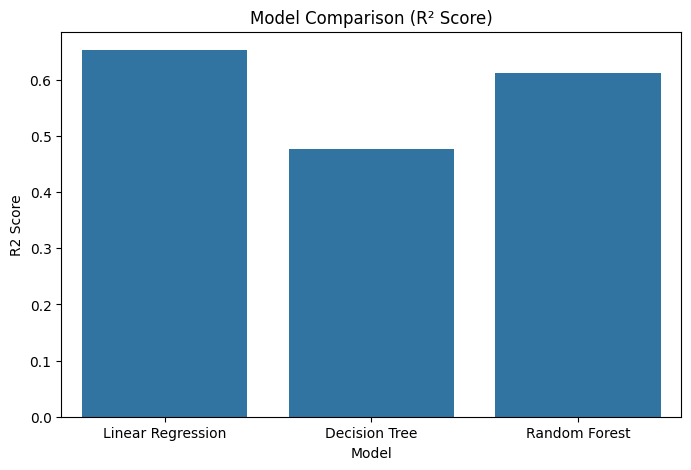

In [19]:
plt.figure(figsize=(8,5))

sns.barplot(
    x='Model',
    y='R2 Score',
    data=results
)

plt.title('Model Comparison (R² Score)')

plt.show()

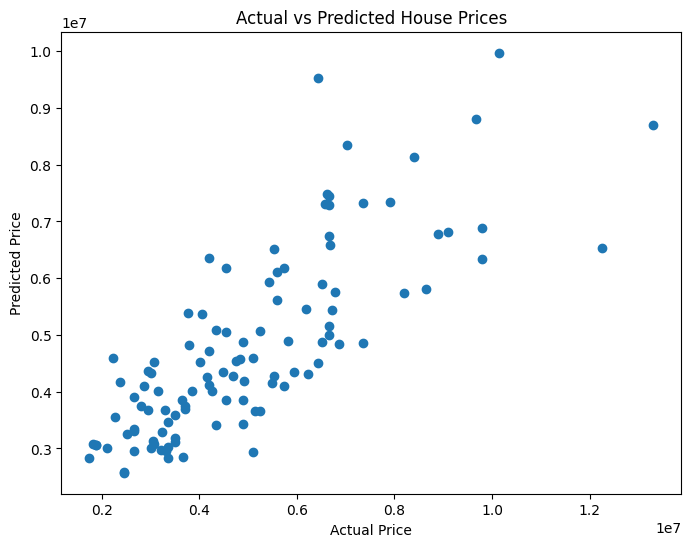

In [20]:
plt.figure(figsize=(8,6))

plt.scatter(
    y_test,
    rf_pred
)

plt.xlabel("Actual Price")

plt.ylabel("Predicted Price")

plt.title(
    "Actual vs Predicted House Prices"
)

plt.show()

In [21]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

importance.head(10)

,Feature,Importance
0,area,0.468430
2,bathrooms,0.151483
9,airconditioning_yes,0.062672
4,parking,0.057455
3,stories,0.057133
1,bedrooms,0.048413
12,furnishingstatus_unfurnished,0.035011
7,basement_yes,0.030823
10,prefarea_yes,0.030689
8,hotwaterheating_yes,0.017226


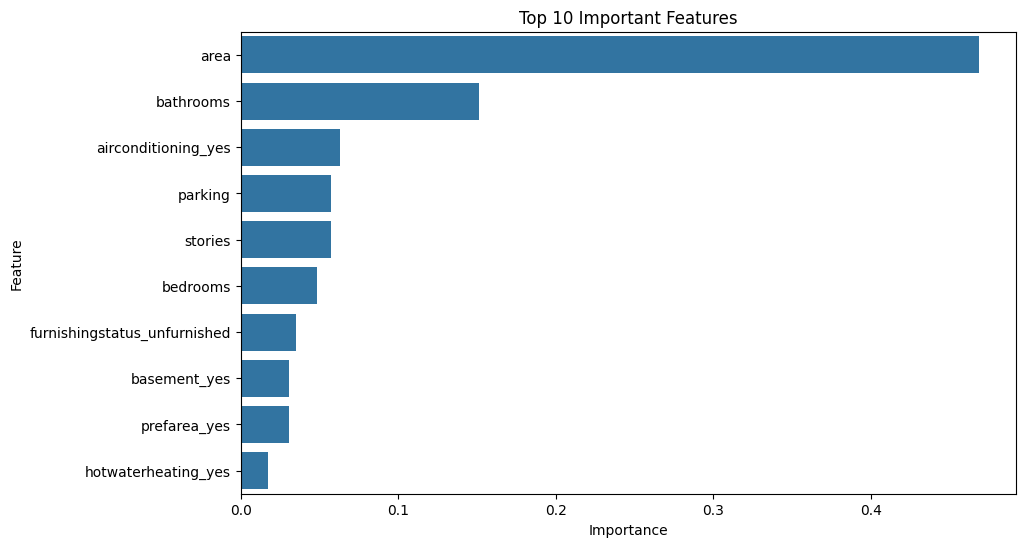

In [22]:
plt.figure(figsize=(10,6))

sns.barplot(
    x='Importance',
    y='Feature',
    data=importance.head(10)
)

plt.title(
    'Top 10 Important Features'
)

plt.show()

In [23]:
print("="*60)
print("HOUSE PRICE PREDICTION REPORT")
print("="*60)

best_model = results.loc[
    results['R2 Score'].idxmax(),
    'Model'
]

print("\nBest Model :", best_model)

print("""
Project Steps Completed:

✓ Data Preprocessing
✓ Feature Encoding
✓ Feature Selection
✓ Train-Test Split
✓ Linear Regression
✓ Decision Tree
✓ Random Forest
✓ Model Evaluation
✓ Feature Importance Analysis

Evaluation Metrics:

RMSE -> Lower is Better
MAE  -> Lower is Better
R²   -> Higher is Better
""")

HOUSE PRICE PREDICTION REPORT

Best Model : Linear Regression

Project Steps Completed:

✓ Data Preprocessing
✓ Feature Encoding
✓ Feature Selection
✓ Train-Test Split
✓ Linear Regression
✓ Decision Tree
✓ Random Forest
✓ Model Evaluation
✓ Feature Importance Analysis

Evaluation Metrics:

RMSE -> Lower is Better
MAE  -> Lower is Better
R²   -> Higher is Better

